In [23]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [24]:
gs = []
df = pd.read_csv('climatechange-opinions.csv')
for i in range(1,4+1):
    g = nx.DiGraph()

    edges = pd.read_csv(f'climatechange-{i}.csv', header=None, names=['u', 'v', 'w'])
    for _, row in edges.iterrows():
        g.add_edge(str(row['u']), str(row['v']), weight=int(row['w']))

    df_t = df[df.t == i]
    opinion = dict(zip(df_t['author'].astype(str), df_t['opinion'].apply(round, args=[3])))
    nx.set_node_attributes(g, opinion, 'opinion')
    
    gs.append(g)

In [25]:
# TABLE 1
rows = []

for i, g in enumerate(gs):
    row = [f"Q{i+1}"]
    row.append(len(g))
    row.append(len(g.edges()))
    row.append(round(sum(dict(g.degree()).values())/float(len(g)), 2))
    row.append(len(list(nx.weakly_connected_components(g))[0]))
    attrs = dict(g.nodes(data=True))
    n_sk, n_sup = 0,0
    for n in attrs:
        if attrs[n]['opinion'] > 0:
            n_sk +=1
        else:
            n_sup +=1
    row.append(n_sup)
    row.append(n_sk)
    rows.append(row)
    assert n_sup + n_sk == len(g)

tbl = pd.DataFrame(rows, columns=['Quarter', '$|V|$','$|E|$','$k_{avg}$','$|C_{max}|$','#supporters','#skeptics'])
print(tbl.to_latex())

\begin{tabular}{llrrrrrr}
\toprule
 & Quarter & $|V|$ & $|E|$ & $k_{avg}$ & $|C_{max}|$ & #supporters & #skeptics \\
\midrule
0 & Q1 & 23253 & 57128 & 4.910000 & 21069 & 8753 & 14500 \\
1 & Q2 & 28426 & 78913 & 5.550000 & 27373 & 11049 & 17377 \\
2 & Q3 & 30048 & 87749 & 5.840000 & 29443 & 13203 & 16845 \\
3 & Q4 & 19854 & 51964 & 5.230000 & 19358 & 9358 & 10496 \\
\bottomrule
\end{tabular}



In [26]:
from scipy.stats import gaussian_kde, pearsonr
from scipy.signal import find_peaks

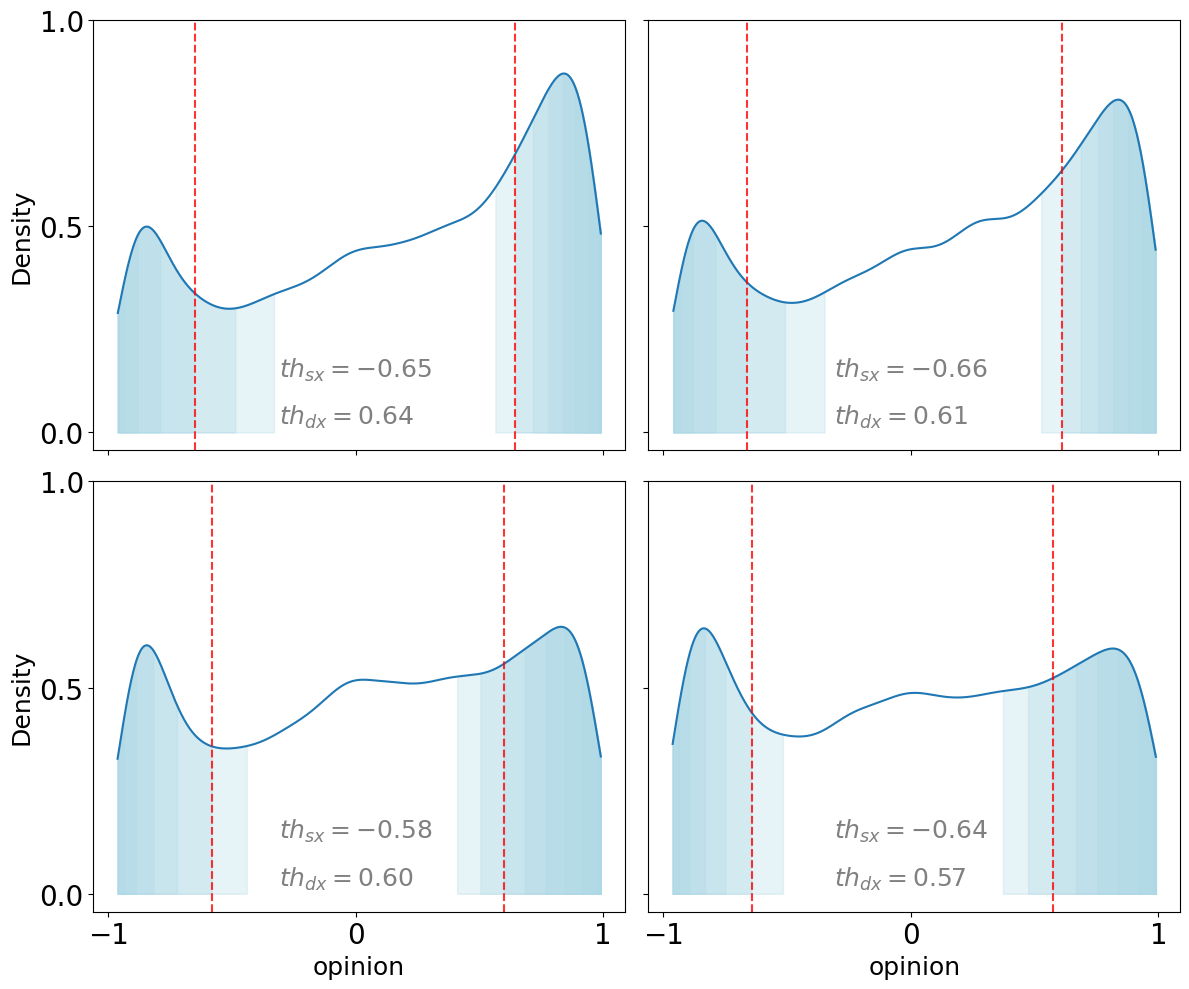

In [27]:
fig, axs = plt.subplots(nrows=2, ncols=2, sharex=True, sharey=True, figsize=(12,10))
thresholds = dict()
for i, g in enumerate(gs):
    ax = axs.flatten()[i]
    attrs = dict(g.nodes(data=True))
    vals =  [attrs[n]['opinion'] for n in g]
    
    # choose percentiles
    percentiles_right_tail = np.percentile(vals, [65, 70, 75, 80, 85, 90, 95, 99])
    percentiles_left_tail = np.percentile(vals, [1, 5, 10, 15, 20, 25])
    xs = np.linspace(min(vals), max(vals), 1000)
    density = gaussian_kde(vals)
    density_vals = density(xs)
    peaks, _ = find_peaks(density_vals)
    right_tail_limit = np.percentile(vals, 65)  
    left_tail_limit = np.percentile(vals, 25) 

    # PLOT
    #for peak in peaks:
    #    if xs[peak] >= right_tail_limit or xs[peak] <= left_tail_limit:
    #        ax.axvline(x=xs[peak], color='red', linestyle='--', alpha=.8)
    for perc in percentiles_right_tail:
        ax.fill_between(xs, 0, density_vals, where=(xs >= perc), color='lightblue', alpha=0.3)
    for perc in percentiles_left_tail:
        ax.fill_between(xs, 0, density_vals, where=(xs <= perc), color='lightblue', alpha=0.3)
    
    ax.plot(xs, density_vals, label='Density')
    ax.set_xticks([-1, 0, 1])
    ax.set_yticks([0, .5, 1])
    ax.tick_params(axis='both', which='major', labelsize=20)

    if i in [0,1]:
        th_sx = np.percentile(vals, 15)
        th_dx = np.percentile(vals, 70)
    else:
        th_sx = np.percentile(vals, 20)
        th_dx = np.percentile(vals, 75)
    ax.axvline(x=th_sx, color='red', linestyle='--', alpha=.8)
    ax.axvline(x=th_dx, color='red', linestyle='--', alpha=.8)
    ax.text(x=0.35, y=0.22, transform = ax.transAxes, s="$th_{sx} =%.2f$" % th_sx,\
        fontsize=18, verticalalignment='top', horizontalalignment='left', color='grey')
    ax.text(x=0.35, y=0.11, transform = ax.transAxes, s="$th_{dx} = %.2f$" % th_dx,\
        fontsize=18, verticalalignment='top', horizontalalignment='left', color='grey')
    
    thresholds[i] = (th_sx, th_dx)
    

axs.flatten()[0].set_ylabel('Density', fontsize=18)
axs.flatten()[2].set_ylabel('Density', fontsize=18)
axs.flatten()[2].set_xlabel('opinion',fontsize=18)
axs.flatten()[3].set_xlabel('opinion',fontsize=18)

plt.tight_layout()
plt.savefig('thresholds-cc.png')

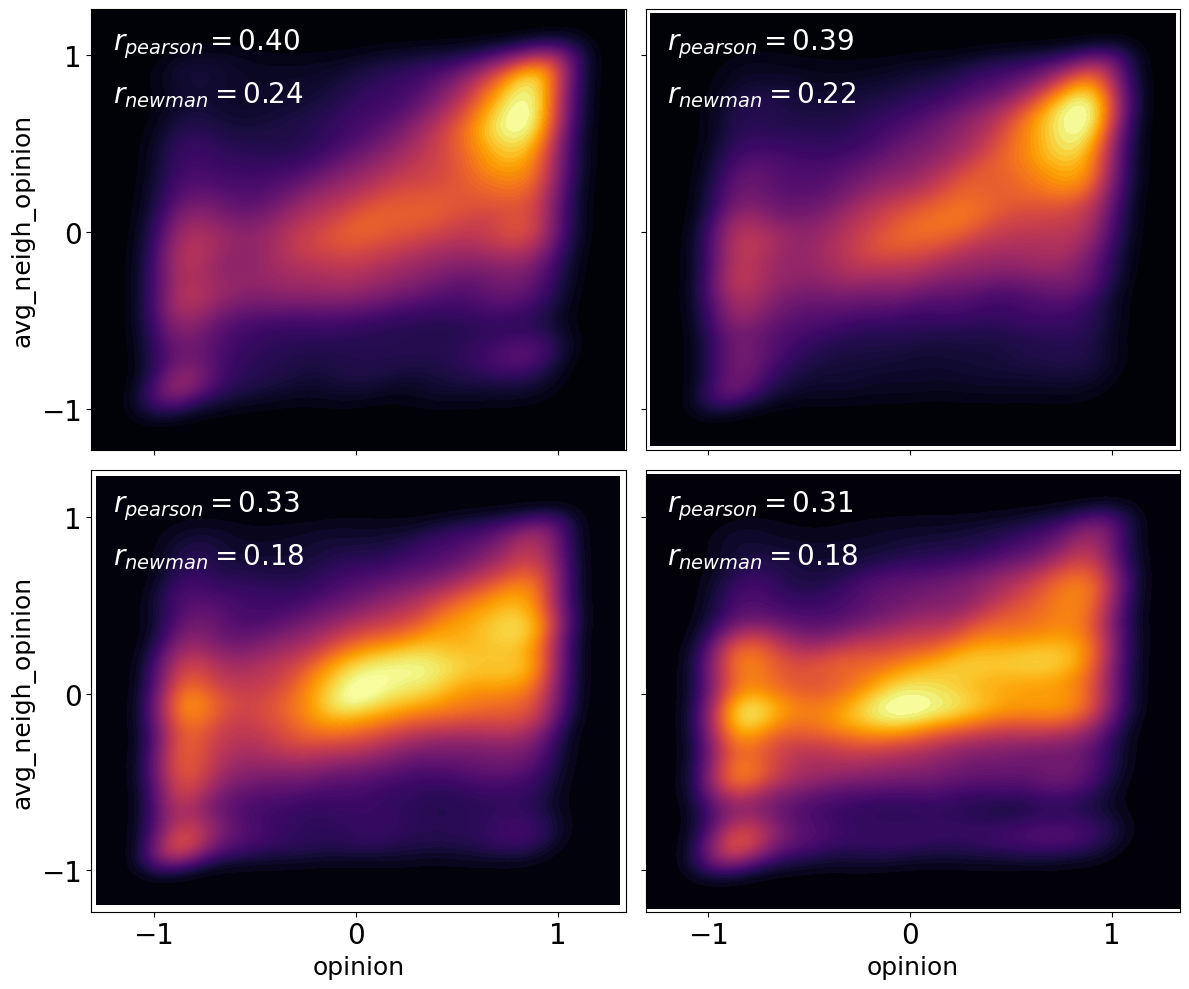

In [28]:
from scipy import stats
fig, axs = plt.subplots(nrows=2, ncols=2, sharex=True, sharey=True, figsize=(12,10))
for i, g in enumerate(gs):
    attrs = dict(g.nodes(data=True))
    os = []
    o1s = []
    for n in attrs:
        o = attrs[n]['opinion']
        o_successors = [attrs[s]['opinion'] for s in g.successors(n)]
        if o_successors:
            o1 = np.mean(o_successors)
            os.append(o)
            o1s.append(o1)
    
    r, p = pearsonr(os, o1s)

    vls = {n: attrs[n]['opinion'] >0 for n in attrs}
    nx.set_node_attributes(g, vls, 'discretized')
    ax = axs.flatten()[i]
    
    newman = nx.attribute_assortativity_coefficient(g, 'discretized')
    ax.text(x=0.04, y=0.96, transform = ax.transAxes, s="$r_{pearson} = %.2f$" % r,\
        fontsize=20, verticalalignment='top', horizontalalignment='left', color='white')
    ax.text(x=0.04, y=0.84, transform = ax.transAxes, s="$r_{newman} = %.2f$" % newman,\
        fontsize=20, verticalalignment='top', horizontalalignment='left', color='white')
    

    ax.set_xticks([-1, 0, 1])
    ax.set_yticks([-1, 0, 1])
    ax.tick_params(axis='both', which='major', labelsize=20)

    
    sns.kdeplot(x=os, y=o1s, fill=True, cmap="inferno", thresh=0, n_levels=100,  ax=ax)
axs.flatten()[0].set_ylabel('avg_neigh_opinion', fontsize=18)
axs.flatten()[2].set_ylabel('avg_neigh_opinion', fontsize=18)
axs.flatten()[2].set_xlabel('opinion',fontsize=18)
axs.flatten()[3].set_xlabel('opinion',fontsize=18)

plt.tight_layout()
plt.savefig('polarization-cc.png')

In [29]:
for i, g in enumerate(gs):
    left, right = thresholds[i]
    is_extreme = dict()
    attrs = dict(g.nodes(data=True))
    for n in g:
        op = attrs[n]['opinion'] 
        if op < left or op > right:
            is_extreme[n] = 1
        else:
            is_extreme[n] = 0
    nx.set_node_attributes(g, is_extreme, 'is_extreme')
        

In [30]:
din = list(d for n, d in g.in_degree())
dout = list(d for n, d in g.out_degree())
cm = nx.directed_configuration_model(din, dout)

In [31]:
def acrophily(g):
    res = dict()
    attrs = dict(g.nodes(data=True))
    for n in attrs:
        n_opinion = attrs[n]['opinion']
        successors = list(g.successors(n))
        if successors:
            # count extremes of same faction
            ext_same = 0
            same_faction =0
            for s in successors:
                s_opinion = attrs[s]['opinion']
                if n_opinion * s_opinion > 0: # same faction
                    same_faction += 1
                    ext_same += attrs[s]['is_extreme'] 
            try:
                res[n] = ext_same/same_faction
            except ZeroDivisionError: # no same faction
                res[n] = None 
        else:
            res[n] = None
    return res


0.2849775112443778
0.2763000239635754
0.2500792823811897
0.25194244604316546


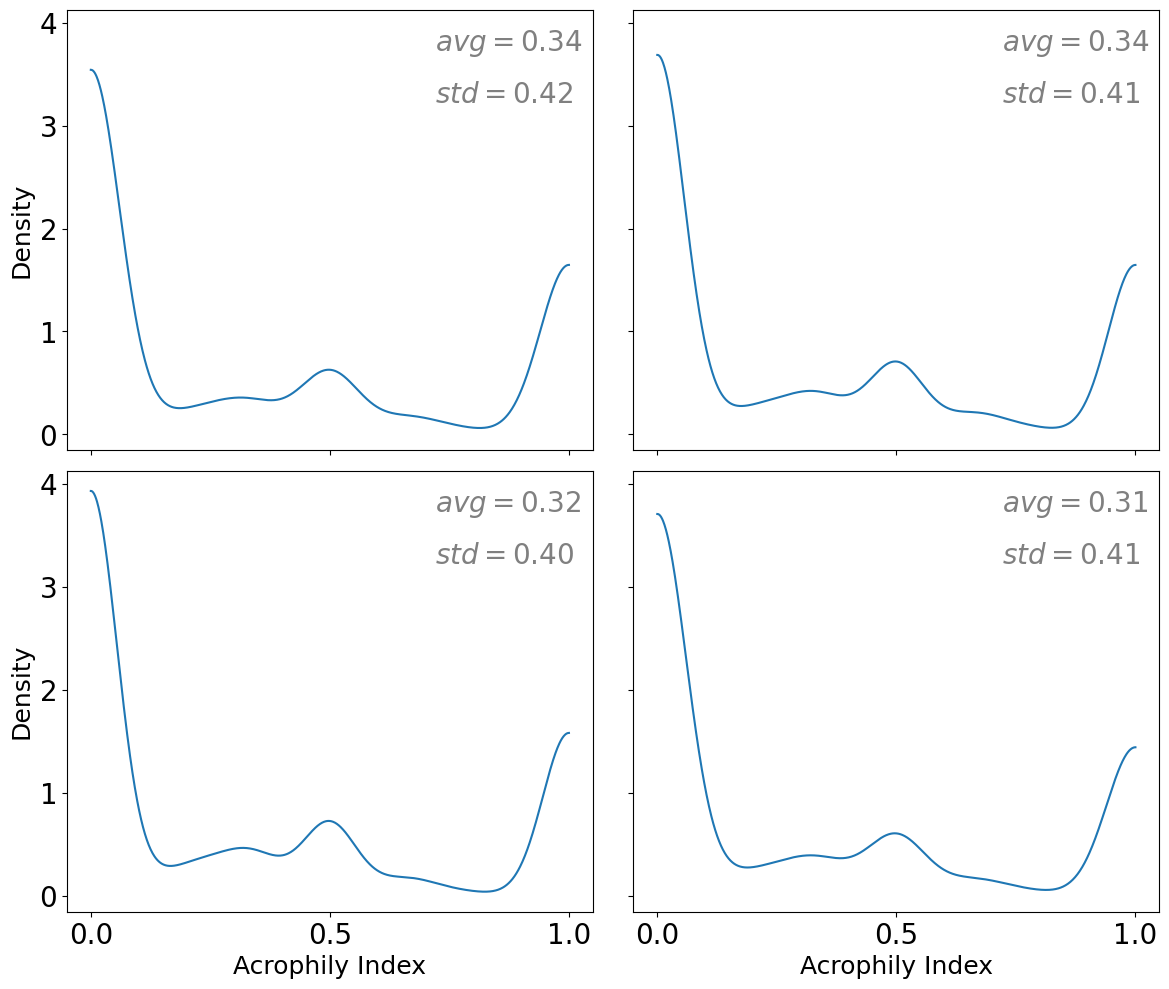

In [32]:
fig, axs = plt.subplots(nrows=2, ncols=2, sharex=True, sharey=True, figsize=(12,10))
for i, g in enumerate(gs):
    ax = axs.flatten()[i]
    acro = acrophily(g)
    acro =  [acro[n] for n in g if acro[n] is not None]
    
    xs = np.linspace(min(acro), max(acro), 1000)
    density = gaussian_kde(acro)
    density_vals = density(xs)
    ax.plot(xs, density_vals, label='Acrophily')

    avg = np.mean(acro)
    std = np.std(acro)
    ax.text(x=0.7, y=0.96, transform = ax.transAxes, s="$avg = %.2f$" % avg,\
        fontsize=20, verticalalignment='top', horizontalalignment='left', color='grey')
    ax.text(x=0.7, y=0.84, transform = ax.transAxes, s="$std = %.2f$" % std,\
        fontsize=20, verticalalignment='top', horizontalalignment='left', color='grey')
    
    ax.set_xticks([0, .5, 1])
    #ax.set_yticks([0, .5, 1])
    ax.tick_params(axis='both', which='major', labelsize=20)
    print(len([x for x in acro if x > 0.5])/len(acro))


axs.flatten()[0].set_ylabel('Density', fontsize=18)
axs.flatten()[2].set_ylabel('Density', fontsize=18)
axs.flatten()[2].set_xlabel('Acrophily Index',fontsize=18)
axs.flatten()[3].set_xlabel('Acrophily Index',fontsize=18)

plt.tight_layout()
plt.savefig('acrophily-cc.png')

In [33]:
res = acrophily(g)
#sns.histplot()

In [34]:
np.mean([val for name, val in res.items()  if val is not None])

np.float64(0.31212309730134613)

In [35]:
def directed_cm(g, th):
    attrs = dict(g.nodes(data=True))
    left, right = th
    din = list(d for n, d in g.in_degree())
    dout = list(d for n, d in g.out_degree())
    cm = nx.directed_configuration_model(din, dout)
    opinions = dict(zip(cm.nodes(), [attrs[n]['opinion'] for n in g]))
    nx.set_node_attributes(cm, opinions, 'opinion')

    is_extreme = dict()
    for n in cm:
        if opinions[n] < left or opinions[n] > right:
            is_extreme[n] =1
        else:
            is_extreme[n] =0
    nx.set_node_attributes(cm, is_extreme, 'is_extreme')
    return cm
    


In [36]:
#aggiunta
def extremophily(g):
    res = dict()
    attrs = dict(g.nodes(data=True))
    for n in attrs:
        n_opinion = attrs[n]['opinion']
        successors = list(g.successors(n))
        if successors:
            more_extreme_same = 0
            same_faction = 0
            for s in successors:
                s_opinion = attrs[s]['opinion']
                if n_opinion * s_opinion > 0:  # same faction
                    same_faction += 1
                    if abs(s_opinion) > abs(n_opinion):
                        more_extreme_same += 1
            try:
                res[n] = more_extreme_same / same_faction
            except ZeroDivisionError:  # no same faction
                res[n] = None
        else:
            res[n] = None
    return res

In [37]:


rows = []
for i, g in enumerate(gs):
    attrs = dict(g.nodes(data=True))
    
    cm = directed_cm(g, thresholds[0])
    cm_attrs = dict(cm.nodes(data=True))


    acro = [v for k, v in acrophily(g).items() if v is not None]
    acro_fake = [v for k, v in acrophily(cm).items() if v is not None]
    acro_avg = np.mean(acro)
    acro_f_avg = np.mean(acro_fake)

    
    extr_fake = [v for k, v in extremophily(cm).items() if v is not None]
    extr = [v for k, v in extremophily(g).items() if v is not None]
    extr_avg = np.mean(extr)
    extr_f_avg = np.mean(extr_fake)


    #row = [i, acro_avg, acro_f_avg, extr_avg, extr_f_avg]

    # COMPUTE average acrophily values for nodes that have 'opinion' attribute > 0


    avg_acro_pos = np.mean([v for k, v in acrophily(g).items() if v is not None and attrs[k]['opinion'] > 0])
    avg_acro_neg = np.mean([v for k, v in acrophily(g).items() if v is not None and attrs[k]['opinion'] < 0])

    avg_acro_pos_fake = np.mean([v for k, v in acrophily(cm).items() if v is not None and cm_attrs[k]['opinion'] > 0])
    avg_acro_neg_fake = np.mean([v for k, v in acrophily(cm).items() if v is not None and cm_attrs[k]['opinion'] < 0])

    avg_extr_pos = np.mean([v for k, v in extremophily(g).items() if v is not None and attrs[k]['opinion'] > 0])
    avg_extr_neg = np.mean([v for k, v in extremophily(g).items() if v is not None and attrs[k]['opinion'] < 0])

    avg_extr_pos_fake = np.mean([v for k, v in extremophily(cm).items() if v is not None and cm_attrs[k]['opinion'] > 0])
    avg_extr_neg_fake = np.mean([v for k, v in extremophily(cm).items() if v is not None and cm_attrs[k]['opinion'] < 0])

    # COMPUTE average acrophily values for nodes that have 'is_extreme' attribute == 1

    avg_acro_extreme = np.mean([v for k, v in acrophily(g).items() if v is not None and attrs[k]['is_extreme'] == 1])
    avg_acro_extreme_fake = np.mean([v for k, v in acrophily(cm).items() if v is not None and cm_attrs[k]['is_extreme'] == 1])

    avg_extr_extreme = np.mean([v for k, v in extremophily(g).items() if v is not None and attrs[k]['is_extreme'] == 1])
    avg_extr_extreme_fake = np.mean([v for k, v in extremophily(cm).items() if v is not None and cm_attrs[k]['is_extreme'] == 1])

    avg_acro_moderate = np.mean([v for k, v in acrophily(g).items() if v is not None and attrs[k]['is_extreme'] == 0])
    avg_acro_moderate_fake = np.mean([v for k, v in acrophily(cm).items() if v is not None and cm_attrs[k]['is_extreme'] == 0])

    avg_extr_moderate = np.mean([v for k, v in extremophily(g).items() if v is not None and attrs[k]['is_extreme'] == 0])
    avg_extr_moderate_fake = np.mean([v for k, v in extremophily(cm).items() if v is not None and cm_attrs[k]['is_extreme'] == 0])

    

    row = [i,  acro_avg, acro_f_avg, extr_avg, extr_f_avg,
           avg_acro_pos, avg_acro_neg, avg_acro_pos_fake, avg_acro_neg_fake, avg_extr_pos, avg_extr_neg, avg_extr_pos_fake, avg_extr_neg_fake,
           avg_acro_extreme, avg_acro_extreme_fake, avg_extr_extreme, avg_extr_extreme_fake, avg_acro_moderate, avg_acro_moderate_fake, avg_extr_moderate, avg_extr_moderate_fake]

    rows.append(row)


import pandas as pd
df = pd.DataFrame(rows, columns=['quarter', 'acro', 'acro_fake', 'extr', 'extr_fake',
                                  'avg_acro_pos', 'avg_acro_neg', 'avg_acro_pos_fake', 'avg_acro_neg_fake',
                                  'avg_extr_pos', 'avg_extr_neg', 'avg_extr_pos_fake', 'avg_extr_neg_fake',
                                  'avg_acro_extreme', 'avg_acro_extreme_fake', 'avg_extr_extreme', 'avg_extr_extreme_fake',
                                  'avg_acro_moderate', 'avg_acro_moderate_fake', 'avg_extr_moderate', 'avg_extr_moderate_fake'])


df_fake = df[['acro_fake', 'extr_fake', 'avg_acro_pos_fake', 'avg_acro_neg_fake', 'avg_extr_pos_fake', 'avg_extr_neg_fake', 'avg_acro_extreme_fake', 'avg_extr_extreme_fake', 'avg_acro_moderate_fake', 'avg_extr_moderate_fake']]
df_real = df[['acro', 'extr', 'avg_acro_pos', 'avg_acro_neg', 'avg_extr_pos', 'avg_extr_neg', 'avg_acro_extreme', 'avg_extr_extreme', 'avg_acro_moderate', 'avg_extr_moderate']]

odds = df_real.values / df_fake.values
odds = pd.DataFrame(odds, columns=['avg_acro', 'extr', 'avg_acro_skept', 'avg_acro_supp', 'avg_extr_skept', 'avg_extr_supp', 'avg_acro_extreme', 'avg_extr_extreme', 'avg_acro_moderate', 'avg_extr_moderate'])


odds = odds[[c for c in odds.columns if 'acro' in c]]

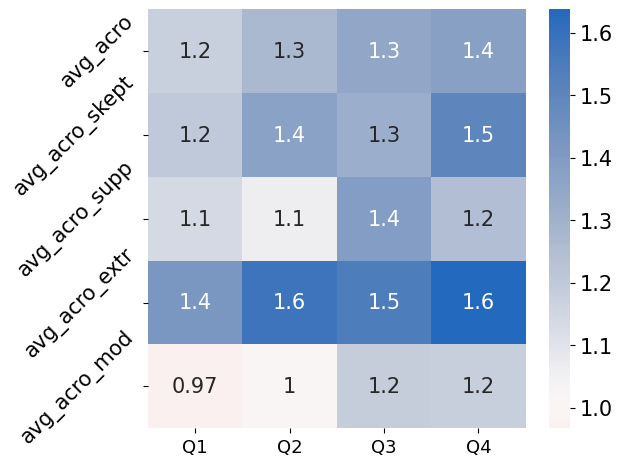

In [38]:
T = odds.transpose()
T.columns = ['Q1', 'Q2', 'Q3', 'Q4']
T.index = ['avg_acro', 'avg_acro_skept', 'avg_acro_supp', 'avg_acro_extr', 'avg_acro_mod']
ax = sns.heatmap(T, annot=True, center=1, 
            annot_kws={"size": 15},
            cmap='vlag_r')
plt.xticks(fontsize=13)
plt.yticks(fontsize=15, rotation=45)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=15)
plt.tight_layout()
plt.savefig('acrophily-matrix-cc.png')

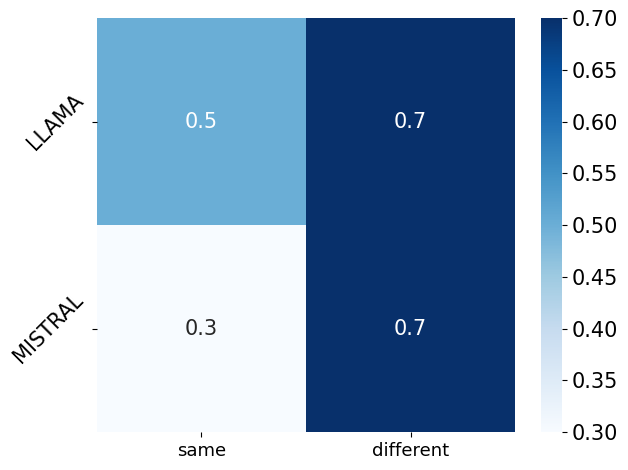

In [39]:
data = [
    [.5, .7],
    [.3, .7],
]
df_toplot = pd.DataFrame(data)
df_toplot.columns = ['same', 'different']
df_toplot.index = ['LLAMA', 'MISTRAL']
ax = sns.heatmap(df_toplot, annot=True,
                 #vmin=0, vmax=1 # se vuoi mettere il colore tra [0,1] anziché tra [min, max]
                 annot_kws={"size": 15}, # size percentuali
                 cmap='Blues')
plt.xticks(fontsize=13)
plt.yticks(fontsize=15, rotation=45)

                 
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=15) # font colorbar
plt.tight_layout()

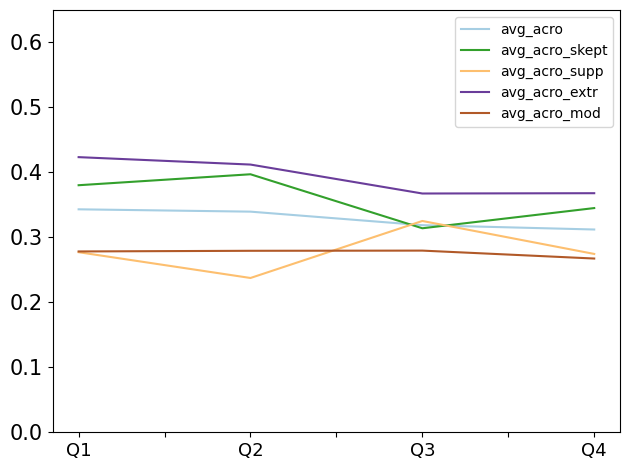

In [40]:
real = pd.DataFrame(df_real.values, columns=['avg_acro', 'extr', 'avg_acro_skept', 'avg_acro_supp', 'avg_extr_skept', 'avg_extr_supp', 'avg_acro_extreme', 'avg_extr_extreme', 'avg_acro_moderate', 'avg_extr_moderate'])
real = real[[c for c in real.columns if 'acro' in c]]
T1= real.transpose()
T1.columns = ['Q1', 'Q2', 'Q3', 'Q4']
T1.index = ['avg_acro', 'avg_acro_skept', 'avg_acro_supp', 'avg_acro_extr', 'avg_acro_mod']
T1.T.plot(colormap='Paired')
plt.ylim(0,.65)
plt.xticks(fontsize=13)
plt.yticks(fontsize=15)
plt.tight_layout()
plt.savefig('acrophily-time-cc.png')

In [41]:
data = []
for i, g in enumerate(gs):
    attrs = dict(g.nodes(data=True))
    for n in g.nodes():
        data.append((i, n, attrs[n]['is_extreme'], attrs[n]['opinion']))

df = pd.DataFrame(data, columns=['t', 'node', 'is_extreme', 'opinion'])
df = df[df.t.isin([0,1])]
def assign_state(row):
    if row['is_extreme'] == 1 and row['opinion'] > 0:
        return 'extreme_skept'
    elif row['is_extreme'] == 1 and row['opinion'] < 0:
        return 'extreme_supp'
    elif row['is_extreme'] == 0 and row['opinion'] > 0:
        return 'moderate_skept'
    elif row['is_extreme'] == 0 and row['opinion'] < 0:
        return 'moderate_supp'
    
df['state'] = df.apply(assign_state, axis=1)
# compute markov chain transition matrix
df['next_state'] = df.groupby('node')['state'].shift(-1)

# count transitions
transitions = df.groupby(['state', 'next_state']).size().reset_index()
# compute transition matrix
transitions['count'] = transitions[0]
transitions = transitions.pivot(index='state', columns='next_state', values='count').fillna(0)
transitions = transitions.div(transitions.sum(axis=1), axis=0)
ordered_states = ['extreme_supp', 'moderate_supp', 'moderate_skept', 'extreme_skept']
transitions = transitions.loc[ordered_states, ordered_states]

<Axes: xlabel='next_state', ylabel='state'>

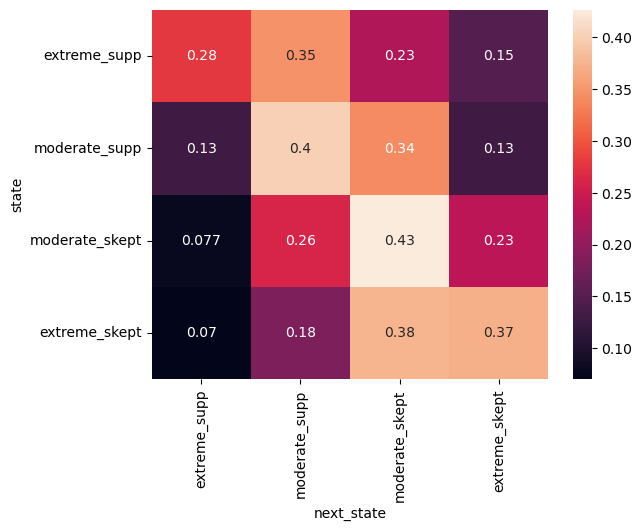

In [42]:
sns.heatmap(transitions, annot=True)

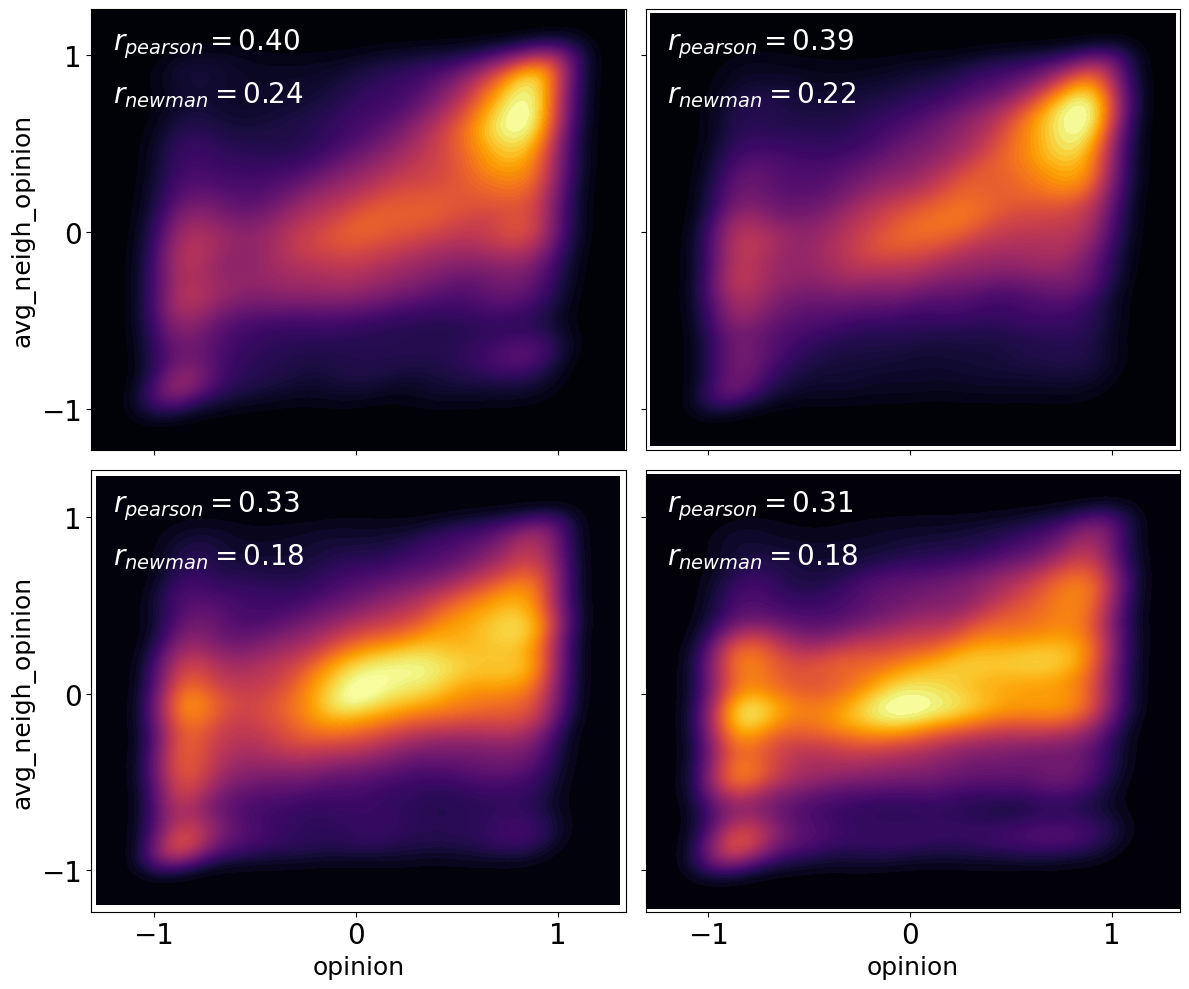

In [43]:
from scipy import stats
fig, axs = plt.subplots(nrows=2, ncols=2, sharex=True, sharey=True, figsize=(12,10))
for i, g in enumerate(gs):
    attrs = dict(g.nodes(data=True))
    os = []
    o1s = []
    for n in attrs:
        o = attrs[n]['opinion']
        o_successors = [attrs[s]['opinion'] for s in g.successors(n)]
        if o_successors:
            o1 = np.mean(o_successors)
            os.append(o)
            o1s.append(o1)
    
    r, p = pearsonr(os, o1s)

    vls = {n: attrs[n]['opinion'] >0 for n in attrs}
    nx.set_node_attributes(g, vls, 'discretized')
    ax = axs.flatten()[i]
    
    newman = nx.attribute_assortativity_coefficient(g, 'discretized')
    ax.text(x=0.04, y=0.96, transform = ax.transAxes, s="$r_{pearson} = %.2f$" % r,\
        fontsize=20, verticalalignment='top', horizontalalignment='left', color='white')
    ax.text(x=0.04, y=0.84, transform = ax.transAxes, s="$r_{newman} = %.2f$" % newman,\
        fontsize=20, verticalalignment='top', horizontalalignment='left', color='white')
    

    ax.set_xticks([-1, 0, 1])
    ax.set_yticks([-1, 0, 1])
    ax.tick_params(axis='both', which='major', labelsize=20)

    
    sns.kdeplot(x=os, y=o1s, fill=True, cmap="inferno", thresh=0, n_levels=100,  ax=ax)
axs.flatten()[0].set_ylabel('avg_neigh_opinion', fontsize=18)
axs.flatten()[2].set_ylabel('avg_neigh_opinion', fontsize=18)
axs.flatten()[2].set_xlabel('opinion',fontsize=18)
axs.flatten()[3].set_xlabel('opinion',fontsize=18)

plt.tight_layout()
plt.savefig('polarization-cc.png')

Nodi giant component: 21069
Archi giant component: 55206
Nodi sottografo: 1524
Archi sottografo: 1964
Nodi sottografo finale: 860
Archi sottografo finale: 1367


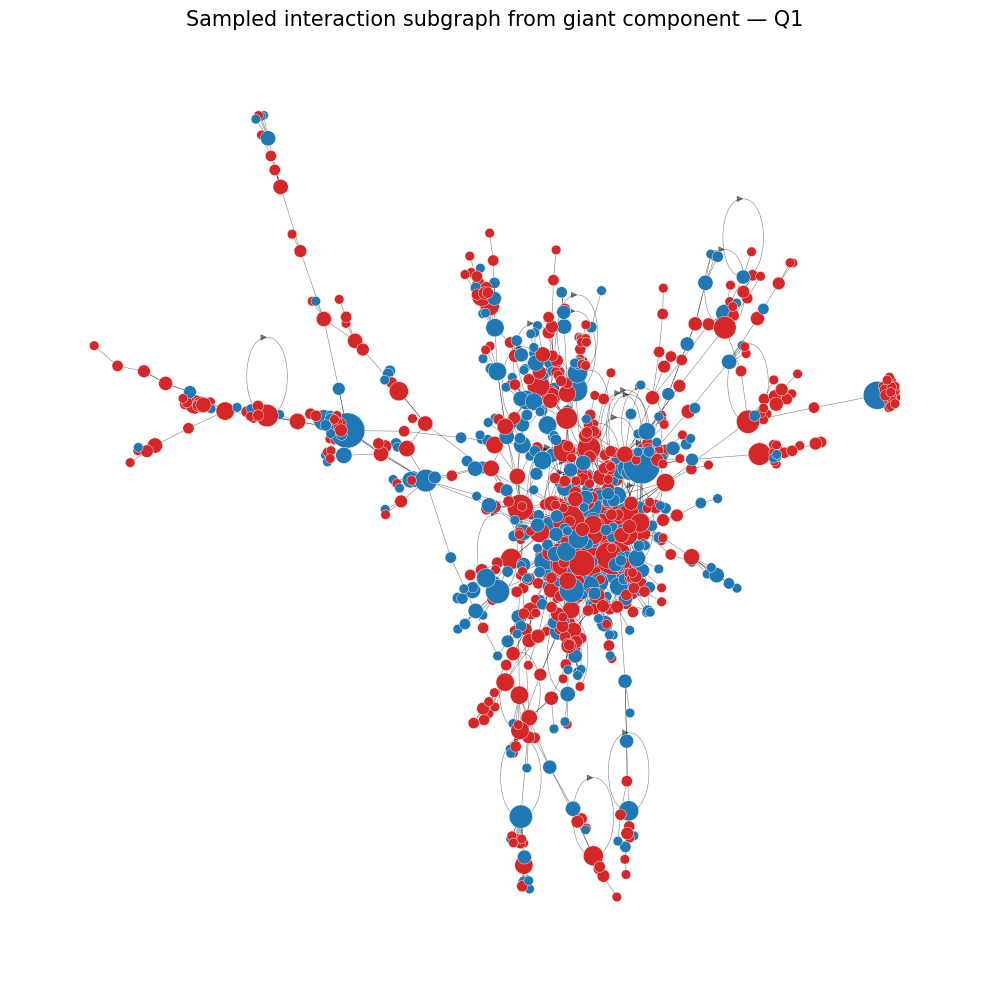

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import random
from matplotlib.lines import Line2D

# =========================
# PARAMETRI
# =========================
quarter_idx = 0      # 0=Q1, 1=Q2, 2=Q3, 3=Q4
n_sample = 4000       # 80-150 consigliato per una slide
seed = 42

# =========================
# GRAFO DEL TRIMESTRE
# =========================
g = gs[quarter_idx]

# componente debolmente connessa più grande
largest_cc = max(nx.weakly_connected_components(g), key=len)
Gcc = g.subgraph(largest_cc).copy()

print(f"Nodi giant component: {Gcc.number_of_nodes()}")
print(f"Archi giant component: {Gcc.number_of_edges()}")

# =========================
# CAMPIONAMENTO NODI
# =========================
random.seed(seed)

if n_sample > Gcc.number_of_nodes():
    n_sample = Gcc.number_of_nodes()

sampled_nodes = random.sample(list(Gcc.nodes()), n_sample)
H = Gcc.subgraph(sampled_nodes).copy()

# rimuovo gli isolati nel sottografo campionato
isolates = list(nx.isolates(H))
H.remove_nodes_from(isolates)

print(f"Nodi sottografo: {H.number_of_nodes()}")
print(f"Archi sottografo: {H.number_of_edges()}")

# =========================
# SOLO COMPONENTE PRINCIPALE DEL SOTTOGRAFO
# (facoltativo ma utile per avere una figura più pulita)
# =========================
if H.number_of_nodes() > 0:
    largest_sub_cc = max(nx.weakly_connected_components(H), key=len)
    H = H.subgraph(largest_sub_cc).copy()

print(f"Nodi sottografo finale: {H.number_of_nodes()}")
print(f"Archi sottografo finale: {H.number_of_edges()}")

# =========================
# LAYOUT
# =========================
pos = nx.spring_layout(H, seed=seed, k=0.7, iterations=100)

# =========================
# COLORI E DIMENSIONI NODI
# =========================
node_colors = []
node_sizes = []

for n in H.nodes():
    opinion = H.nodes[n]['opinion']
    
    # colori per fazione
    if opinion > 0:
        node_colors.append('#d62728')   # rosso = skeptic
    else:
        node_colors.append('#1f77b4')   # blu = supporter
    
    # dimensione proporzionale al grado nel sottografo
    deg = H.degree(n)
    node_sizes.append(30 + deg * 18)

# =========================
# PLOT
# =========================
fig, ax = plt.subplots(figsize=(10, 10), facecolor='white')

nx.draw_networkx_edges(
    H, pos,
    alpha=0.5,
    width=0.4,
    edge_color='black',
    arrows=False,
    ax=ax
)

nx.draw_networkx_nodes(
    H, pos,
    node_color=node_colors,
    node_size=node_sizes,
    edgecolors='white',
    linewidths=0.3,
    ax=ax
)

ax.set_title(f"Sampled interaction subgraph from giant component — Q{quarter_idx+1}", fontsize=15)
ax.axis('off')

plt.tight_layout()
fig.savefig('graph.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()